# Lab 12 Image Retrieval: Task 3 Baseline

Image retrieval focuses on finding one or more images that are the most similar to a query image. This process requires computing the similarity between the query images and all the search candidates.

Image Retrieval can be a supervised task, when there are catalogues that rank a subset of candidate images according to their similarity to some query image. Nevertheless, as we do not possess a ground-truth for the pool tables, we will consider alternative methods to compute the similarity between images and use it to retrieve images.

In [1]:
import torch
from torchvision.transforms import v2 as transforms
from torch.nn import functional as F
import torchvision
import matplotlib.pyplot as plt
import os, random, re
import pandas as pd
import numpy as np
from PIL import Image

In [3]:
import os, shutil, glob
import pandas as pd

# The retrieval images named in partition.csv live scattered across the detection
# dataset's train/valid/test folders. Gather them into a single 'images/' folder
# (this replaces the original `!unzip images.zip`).
DATASET_DIR = "dataset"     # adjust to your dataset root
IMAGES_DIR  = "images"
PARTITION   = "partition.csv"

os.makedirs(IMAGES_DIR, exist_ok=True)
index = {os.path.basename(p): p
         for p in glob.glob(os.path.join(DATASET_DIR, "**", "*.jpg"), recursive=True)}

df_part = pd.read_csv(PARTITION)
found, missing = 0, []
for name in df_part["image_name"]:
    src = index.get(name)
    if src is None:
        missing.append(name); continue
    dst = os.path.join(IMAGES_DIR, name)
    if not os.path.exists(dst):
        shutil.copy(src, dst)
    found += 1
print(f"Copied/verified {found}/{len(df_part)} images into '{IMAGES_DIR}/'")
if missing:
    print(f"WARNING: {len(missing)} names not found in {DATASET_DIR}:", missing[:5])


Copied/verified 247/247 images into 'images/'


### Data Preparation

One of the first steps in an image retrieval pipeline is to define the retrieval pool: the set of candidate images among which we want to retrieve the most similar image to a query image.

This set can be the entire training data. Nevertheless, in large datasets, it may be computationally unfeasible to calculate the similarity between the query image and all the data instances. As such, in these cases, we may want to first select a subset of images that can represent our data (e.g., through clustering techniques to find a subset of images that are representative of the entire data).

Since the pool dataset is small, we will consider the entire training data as our retrieval pool.

Let's start by loading the data.

In [4]:
class PoolDataset:
    def __init__(self, root, partition_file, partition, transform=None):
        self.root = root
        partition_file = pd.read_csv(partition_file)

        idx = np.where(np.asarray(partition_file['partition'].values) == partition)[0]
        self.files = np.asarray(partition_file['image_name'].values)[idx]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image = Image.open(os.path.join(self.root, self.files[i]))
        if self.transform:
            image = self.transform(image)
        return image

Define transformations to be applied to the images and data loaders

In [5]:
# Define transformations to be applied to validation data
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Define dataloader for the retrieval pool (training data) and query images (test data)
retrieval_pool = PoolDataset('images', 'partition.csv', 'train', val_transform)
query_data = PoolDataset('images', 'partition.csv', 'test', val_transform)

As a use case, let's consider the first test image.

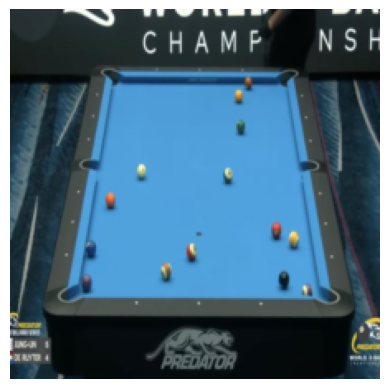

In [6]:
query_image = query_data[0]
query_image_show = query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
plt.imshow(query_image_show)
_ = plt.axis("off")

Now that we have both the retrieval pool and query data ready to be used, we can start developing the retrieval methods.

The second step in a retrieval pipeline, after defining the retrieval pool and loading the data, is to define a similarity (or distance) measurement to compare the query image with each of the candidates.

We can compute the similarity between two images on two different levels:
* Image Level Similarity: Measurements computed based on the pixels of the two images.
* Representation-Level Similarity: Measurements computed based on the representations of the two images, obtained through a feature extraction network.

## Retrieval using Image Level Similarity

Let's start by using image-level similarity measurements for retrieving the top-5 most similar images. In this example, we will consider two similarity/distance measurements, available on skimage:
* Euclidean distance/Mean Squared Error: distance measurement (where lower values indicate higher similarity) between the pixels of the two images.
* Structural similarity: similarity measurement (where higher values indicate higher similarity) that considers the structure, luminance and contrast of the image rather than simply comparing the distance between pixels in identical locations of the two images.

In [7]:
from skimage.metrics import mean_squared_error, structural_similarity

### Mean Squared Error

Calculate the distance between the query and retrieval candidates and select the top-5 images.

In [8]:
similarities = np.zeros((len(retrieval_pool),))
for i in range(len(retrieval_pool)):
  # calculate the distance between the query image and each candidate
  # torch tensors must be transformed into numpy vectors before computing the mean squared error using skimage
  similarities[i] = mean_squared_error(query_image.numpy(), retrieval_pool[i].numpy())

# select the indexes of the top-5 most similar images
top5_idx = np.argsort(similarities)[:5]  # smallest distance = most similar

Show the top-5 images.

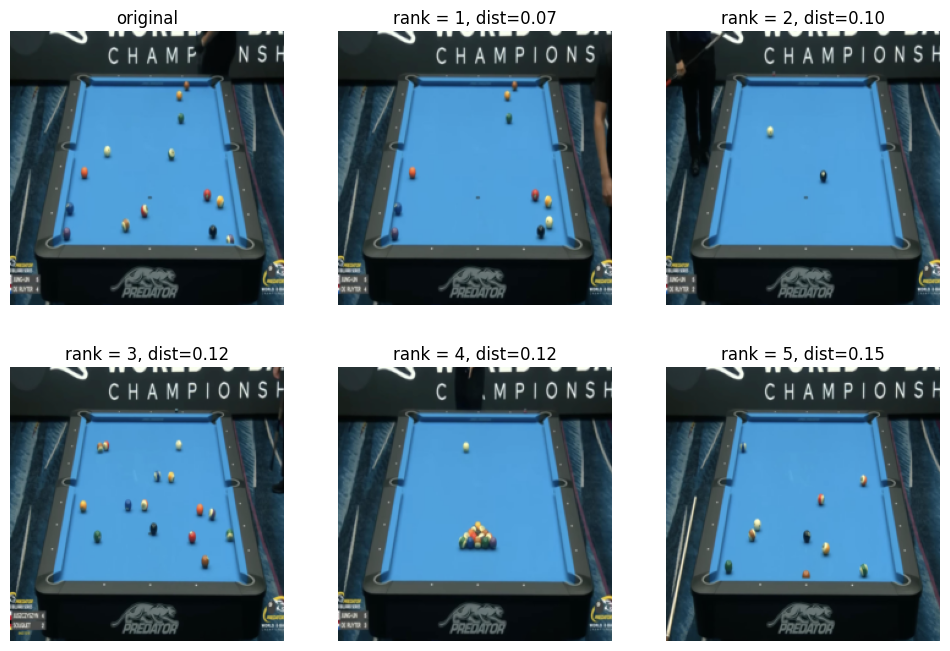

In [9]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = retrieval_pool[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist={similarities[top5_idx[j-1]]:.2f}")
  axarr[j // 3][j % 3].axis("off")

Since we do not have a ground-truth to compare the results of retrieval, we need to consider other ways to evaluate the results. Since we want to obtain similar pool tables, whose balls are located in similar positions relative to the table (independently of the view), then, intuitively, the query image should be more similar to itself, after applying some transformation that preserves relative ball position (e.g., translation), than any other image of a pool table.

As a sanity check, let's use the previous similarity/distance measurement to compare the similarity between the query and its most similar image with the similarity between the query and itself, after a small transformation.

Apply a translation of 5 pixels to the query image and compare the distance obtained between the query and its translated version with the distance between the query and the top1 retrieval result.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

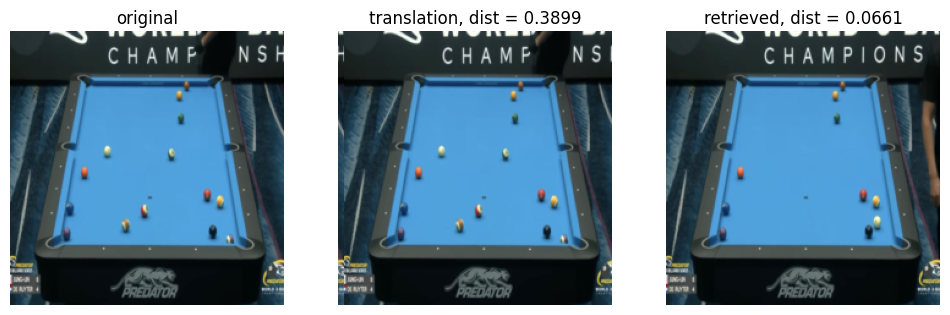

In [10]:
# apply translation of 5 pixels to the right to the query image
translate_query_image = torch.roll(query_image, shifts=5, dims=2)  # 5 px to the right (width axis)
# calculate the mean squared error between the query and its translated version
sim_trans = mean_squared_error(query_image.numpy(), translate_query_image.numpy())

f, axarr = plt.subplots(1, 3, figsize=(12, 4))
axarr[0].imshow(query_image_show)
axarr[0].set_title("original")
axarr[0].axis("off")

translate_query_image_show = translate_query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[1].imshow(translate_query_image_show)
axarr[1].set_title(f"translation, dist = {sim_trans:.4f}")
axarr[1].axis("off")

img_show = retrieval_pool[top5_idx[0]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[2].imshow(img_show)
axarr[2].set_title(f"retrieved, dist = {similarities[top5_idx[0]]:.4f}")
axarr[2].axis("off")

What can you conclude from this sanity check?

### Structural Similarity Index Measure

Now, let's repeat the retrieval process but with the structural similarity index measure. This measure provides values in the range [0, 1], where 1 represents the maximum similarity possible between two images.

In [11]:
similarities = np.zeros((len(retrieval_pool),))
for i in range(len(retrieval_pool)):
  # calculate the similarities between the query image and the candidate using structural similarity 
  cand = retrieval_pool[i].numpy()
  similarities[i] = structural_similarity(query_image.numpy(), cand, channel_axis=0, data_range=float(cand.max() - cand.min()))

# select the indexes of the top-5 most similar images
top5_idx = np.argsort(similarities)[::-1][:5]  # higher SSIM = more similar

Show the results.

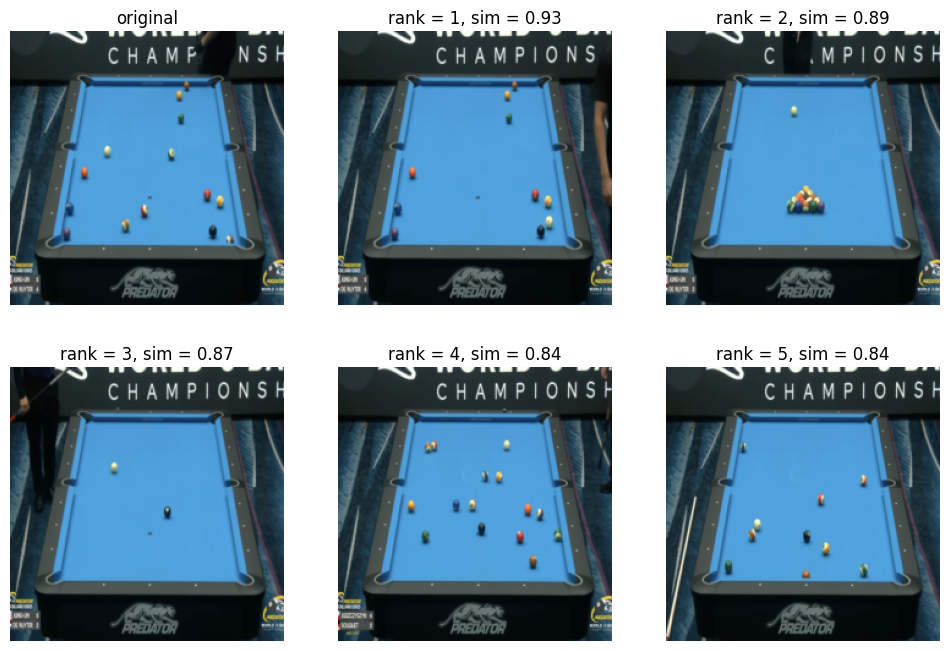

In [12]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = retrieval_pool[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, sim = {similarities[top5_idx[j-1]]:.2f}")
  axarr[j // 3][j % 3].axis("off")

Perform sanity check.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

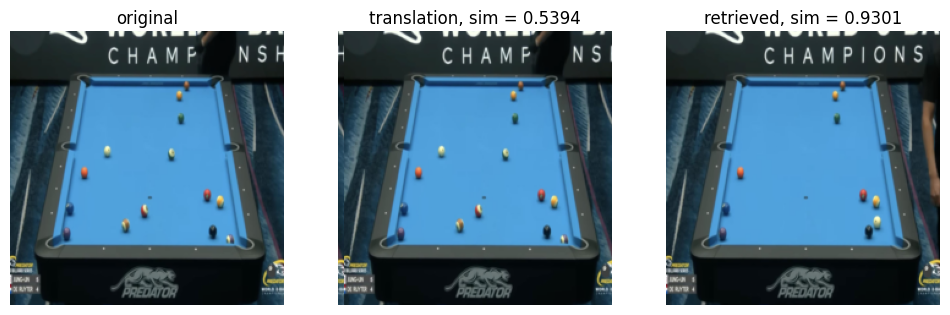

In [13]:
# apply translation of 5 pixels to the right to the query image
translate_query_image = torch.roll(query_image, shifts=5, dims=2)
# calculate the structural similarity between the query and its translated version
q_np, t_np = query_image.numpy(), translate_query_image.numpy()
sim_trans = structural_similarity(q_np, t_np, channel_axis=0, data_range=float(max(q_np.max(), t_np.max()) - min(q_np.min(), t_np.min())))

f, axarr = plt.subplots(1, 3, figsize=(12, 4))
axarr[0].imshow(query_image_show)
axarr[0].set_title("original")
axarr[0].axis("off")

translate_query_image_show = translate_query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[1].imshow(translate_query_image_show)
axarr[1].set_title(f"translation, sim = {sim_trans:.4f}")
axarr[1].axis("off")

img_show = retrieval_pool[top5_idx[0]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[2].imshow(img_show)
axarr[2].set_title(f"retrieved, sim = {similarities[top5_idx[0]]:.4f}")
axarr[2].axis("off")

Notice how all the images retrieved using image-level similarity measurements have the exact same pose. The problem with these metrics is that they only take into consideration pixel-level or structural similarity, while disregarding semantic information. In the image retrieval task, we are more concerned with obtaining pool tables with balls located in similar positions relative to the table, rather than just obtaining tables in similar poses. As such, we need to develop models capable of capturing semantic information.

## Retrieval using Representation-Level Similarity with a Pretrained Model

As a first step towards considering semantic information in the retrieval task, let's leverage the capacity of deep learning models to extract semantically rich features from images. Let's start by using the backbone of a pretrained model (e.g. ResNet) to extract features from images and measure their similarity.

In [14]:
class FeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # load resnet backbone (or any other backbone of your choosing)
        backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        # get the feature extractor of the pretrained model (by removing the classification head from the model)
        self.encoder = torch.nn.Sequential(*list(backbone.children())[:-1])  # drop the fc head
        # freeze the model
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        x = self.encoder(x)
        return x

In [15]:
model = FeatureExtractor()

Now that we have a model that translates images into vectorial representations, we can use it to calculate the distance (or similarity) between images. Like in image-level similarity, we also need to define a similarity/distance measure to compare the vectorial representations. Common measurements include:
* Mean squared error
* Cosine similarity

Note that structural similarity is an image similarity metric and cannot be used with vectorial representations.

In [16]:
# apply model to obtain the representation of the query image
model.eval()
query_features = model(query_image.unsqueeze(0)).flatten().detach().numpy()

similarities = np.zeros((len(retrieval_pool),))
for i in range(len(retrieval_pool)):
  # apply model to obtain the representation of the retrieval candidate
  train_features = model(retrieval_pool[i].unsqueeze(0)).flatten().detach().numpy()
  # compute mean squared error distance between query and candidate representations
  similarities[i] = mean_squared_error(query_features, train_features)

# get indexes of top 5 most similar images
top5_idx = np.argsort(similarities)[:5]

Show the results.

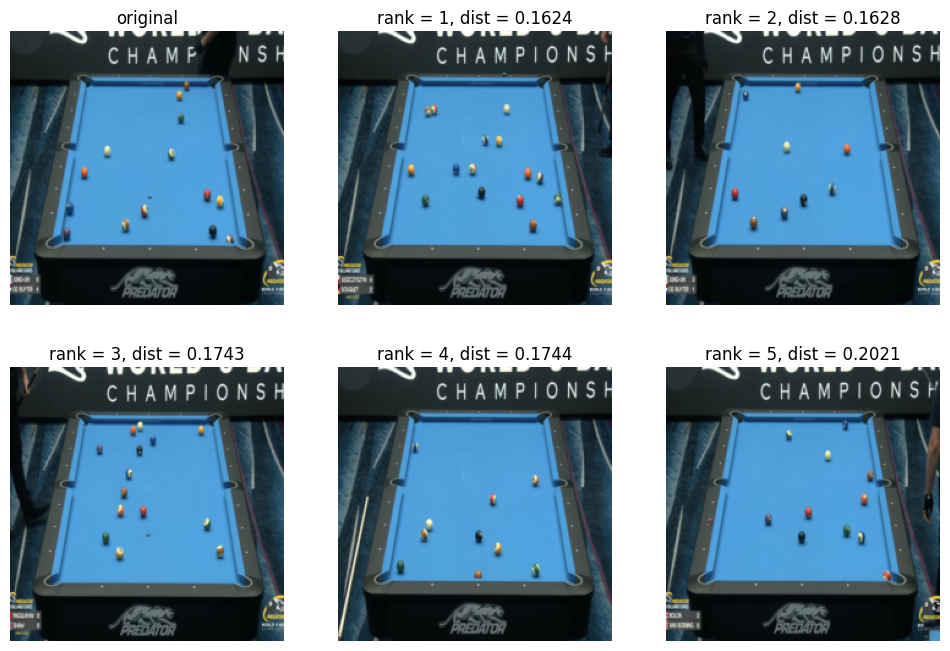

In [17]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = retrieval_pool[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist = {similarities[top5_idx[j-1]]:.4f}")
  axarr[j // 3][j % 3].axis("off")

Perform sanity check.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

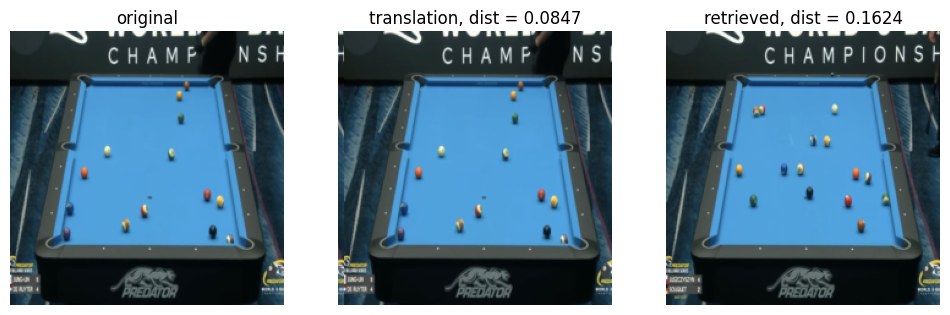

In [18]:
# apply translation of 5 pixels to the query image
translate_query_image = torch.roll(query_image, shifts=5, dims=2)
# get the augmented image's features
translate_query_features = model(translate_query_image.unsqueeze(0)).flatten().detach().numpy()
# calculate the mean squared error between the features of the query image and its augmented version
sim_trans = mean_squared_error(query_features, translate_query_features)

f, axarr = plt.subplots(1, 3, figsize=(12, 4))
axarr[0].imshow(query_image_show)
axarr[0].set_title("original")
axarr[0].axis("off")

translate_query_image_show = translate_query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[1].imshow(translate_query_image_show)
axarr[1].set_title(f"translation, dist = {sim_trans:.4f}")
axarr[1].axis("off")

img_show = retrieval_pool[top5_idx[0]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[2].imshow(img_show)
axarr[2].set_title(f"retrieved, dist = {similarities[top5_idx[0]]:.4f}")
axarr[2].axis("off")

The pretrained model was not optimized on the pool dataset and, thus, has a limited capacity to capture semantically meaningful features. As such, this model may not be ideal for the retrieval task, and may need to be optimized for this task. As there are no ground-truth labels for retrieval, we can consider two main methods for optimizing the feature extractor:
 * Direct optimization: Directly optimizing the feature extractor by computing some loss function directly on the features extracted by the feature extractor - we need to decide which loss function and associated training technique can be used to optimize the network for retrieval
 * Proxy Task: Training the feature extractor as part of a network developed for a task other than retrieval, but that requires extracting rich semantic features relative to the pool game from the image - we need to decide which task can be used for this


## Optimizing the Pretrained Model for Retrieval through Direct Optimization



In the retrieval task, an image should always be the most similar to itself, independently of any transformation that does not change the relative position of the balls. Through the sanity checks, we saw that previous methods did not consider the query image to be similar to itself after a very small translation. To fix this behaviour, we can directly optimize the feature extractor to minimize the distance to itself.

Nevertheless, simply minimizing the distance between augmented versions of the same image is not enough as it can lead to the network simply compacting the latent space and minimizing the distance between all data samples. As such, we also need to maximize the distance between different images.

This training process with a loss function where we minimize the distance between specific data samples while maximizing it for other samples is called Contrastive Learning. In contrastive learning, we need positive pairs with samples whose distance we want to minimize, and negative pairs whose distance we want to maximize. To account for data imbalance, let's build a data loader that can be used to obtain three samples at once: the original image, its augmented version and a randomly selected image.

In [19]:
class TripletPoolDataset:
    def __init__(self, root, partition_file, partition, transform=None, val_transform=None):
        self.root = root
        partition_file = pd.read_csv(partition_file)

        idx = np.where(np.asarray(partition_file['partition'].values) == partition)[0]
        self.files = np.asarray(partition_file['image_name'].values)[idx]
        self.transform = transform
        self.val_transform = val_transform
        self.partition = partition

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image = Image.open(os.path.join(self.root, self.files[i]))

        if self.partition == "train":
            # select a random image of the data (except the current image at index i)
            candidate_idx = np.concatenate((np.arange(len(self.files)-1)[:i], np.arange(len(self.files)-1)[i+1:]))
            neg_idx = random.choice(candidate_idx)
        else:
            # in the validation set, we need to make sure that the negative pair is always the same 
            # to better monitor the performance of the model
            neg_idx = i+1
            if neg_idx >= len(self.files):
                neg_idx = 0

        neg_image = Image.open(os.path.join(self.root, self.files[neg_idx]))

        # apply transformations to the query, negative (randomly selected) sample and positive (augmented) sample
        image_query = self.val_transform(image)        # clean anchor
        image_pos = self.transform(image)             # augmented view of the SAME image (positive)
        image_neg = self.val_transform(neg_image)      # a DIFFERENT image (negative)

        return image_query, image_pos, image_neg

Define datasets and data loaders.

In [20]:
aug_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = TripletPoolDataset('images', 'partition.csv', 'train', aug_transform, val_transform)
val_dataset = TripletPoolDataset('images', 'partition.csv', 'valid', aug_transform, val_transform)

batch_size = 8
num_workers = 1
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, num_workers=num_workers)

Define the Feature Extractor model.

In [21]:
class FeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # load resnet backbone (or any other backbone of your choosing)
        backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        # get the feature extractor of the pretrained model (by removing the classification head from the model)
        self.encoder = torch.nn.Sequential(*list(backbone.children())[:-1])  # 512-d features (trainable)
        # this time we want to train the encoder, so we do not freeze it

    def forward(self, x):
        x = self.encoder(x)
        return x

In [22]:
# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)

# create model
model = FeatureExtractor()
model = model.to(device)

using device: cuda


In [23]:
# Define optimizer
optimizer = torch.optim.AdamW(model.parameters())
epochs = 20

# Define loss
loss_fn = torch.nn.MSELoss(reduction="none")

Define one epoch of the training process. Here, we need to define the contrastive loss function where we maximize the distance between the query image and a randomly selected image of the data (negative sample) and minimize the distance between the query and its augmented version (positive sample).

Note that, when maximizing the distance without any restrictions, the network may lead to infinitely large distances, leading to a sparse latent space. To avoid this, we can restrict the maximum distance between two different samples by defining a margin value such that any value above that margin would lead to the exact same loss (i.e., clip the distance so that it does not go beyond the margin when computing the loss).

In [24]:
def one_epoch(model, optimizer, dataloader, is_training):
  model.train() if is_training else model.eval()
  avg_loss = 0
  for i, (image_query, image_pos, image_neg) in enumerate(dataloader):
    image_query = image_query.to(device)
    image_pos = image_pos.to(device)
    image_neg = image_neg.to(device)
    # extract representations of the query, positive and negative samples using the feature extractor
    rep_query = model(image_query).flatten(1)   # (B, 512)
    rep_pos = model(image_pos).flatten(1)
    rep_neg = model(image_neg).flatten(1)

    # implement here the loss term to minimize the distance between the query and positive sample
    loss = torch.mean(loss_fn(rep_query, rep_pos))   # pull anchor & positive (augmented self) together
    # loss term to maximize the distance between the query and the negative (random) sample
    m = 1.
    d_neg = loss_fn(rep_query, rep_neg).mean(dim=1)            # (B,) per-sample distance
    loss = loss + torch.mean(torch.clamp(m - d_neg, min=0.0))  # push anchor & negative apart up to margin m
    
    if is_training:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss += loss.item() / len(dataloader)
  return avg_loss

Train the model (note that in contrastive learning, we usually need to train the network for a large number of epochs).

In [25]:
train_history = {'loss': [], 'metric': []}
val_history = {'loss': [], 'metric': []}
for epoch in range(epochs):
  # compute train
  avg_loss = one_epoch(model, optimizer, train_dataloader, True)
  train_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Train loss: {avg_loss}')
  # compute validation statistics
  avg_loss = one_epoch(model, optimizer, val_dataloader, False)
  val_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Val   loss: {avg_loss}')

MIOpen(HIP): Warning [FindSolutionImpl] Invalid config loaded from Perf Db: ConvBinWinogradRxSf3x2: 38. Performance may degrade.
MIOpen(HIP): Warning [FindSolutionImpl] Invalid config loaded from Perf Db: ConvBinWinogradRxSf3x2: 56. Performance may degrade.
MIOpen(HIP): Warning [FindSolutionImpl] Invalid config loaded from Perf Db: ConvBinWinogradRxSf3x2: 40. Performance may degrade.
MIOpen(HIP): Warning [FindSolutionImpl] Invalid config loaded from Perf Db: ConvBinWinogradRxSf3x2: 39. Performance may degrade.


Epoch  1/20 - Train loss: 0.3133168757821505
Epoch  1/20 - Val   loss: 0.4100731387734413
Epoch  2/20 - Train loss: 0.2767902217232264
Epoch  2/20 - Val   loss: 0.7420642574628195
Epoch  3/20 - Train loss: 0.3031229342405613
Epoch  3/20 - Val   loss: 0.49475695689519245
Epoch  4/20 - Train loss: 0.3116234139754222
Epoch  4/20 - Val   loss: 0.5854662160078684
Epoch  5/20 - Train loss: 0.3521577532474811
Epoch  5/20 - Val   loss: 0.38635453085104626
Epoch  6/20 - Train loss: 0.3252350805470576
Epoch  6/20 - Val   loss: 0.4967483381430308
Epoch  7/20 - Train loss: 0.40151632577180857
Epoch  7/20 - Val   loss: 0.45095934470494586
Epoch  8/20 - Train loss: 0.263131739714971
Epoch  8/20 - Val   loss: 0.4328611095746358
Epoch  9/20 - Train loss: 0.22374825466137663
Epoch  9/20 - Val   loss: 0.5238883097966512
Epoch 10/20 - Train loss: 0.2473504849924491
Epoch 10/20 - Val   loss: 0.5487644970417023
Epoch 11/20 - Train loss: 0.25897111342503476
Epoch 11/20 - Val   loss: 0.38262691100438434
Epoc

Get the top-5 most similar images.

In [26]:
# apply model to obtain the representation of the query image
model.eval()
query_features = model(query_image.unsqueeze(0).to(device)).flatten().detach().cpu().numpy()

similarities = np.zeros((len(retrieval_pool),))
for i in range(len(retrieval_pool)):
  # apply model to obtain the representation of the retrieval candidate
  train_features = model(retrieval_pool[i].unsqueeze(0).to(device)).flatten().detach().cpu().numpy()
  # compute mean squared error distance between query and candidate representations
  similarities[i] = mean_squared_error(query_features, train_features)

# get indexes of top 5 most similar images
top5_idx = np.argsort(similarities)[:5]

Show the results.

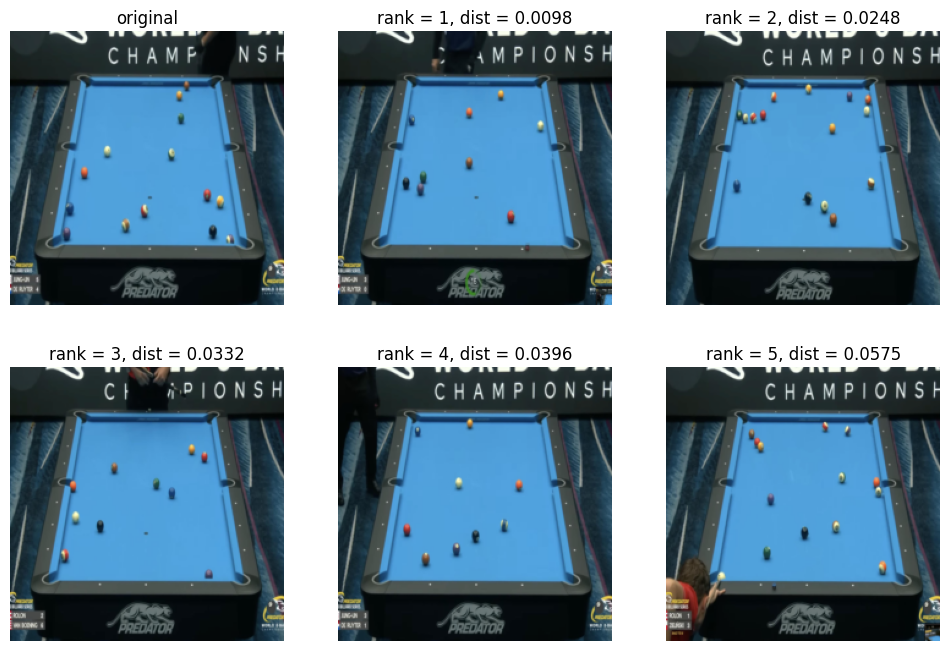

In [27]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = retrieval_pool[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist = {similarities[top5_idx[j-1]]:.4f}")
  axarr[j // 3][j % 3].axis("off")

Perform sanity check.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

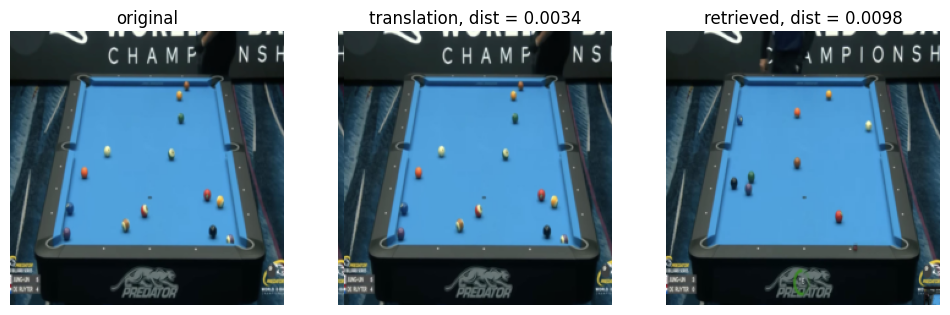

In [28]:
# apply translation of 5 pixels to the query image
translate_query_image = torch.roll(query_image, shifts=5, dims=2)
# get the augmented image's features
translate_query_features = model(translate_query_image.unsqueeze(0).to(device)).flatten().detach().cpu().numpy()
# calculate the mean squared error between the features of the query image and its augmented version
sim_trans = mean_squared_error(query_features, translate_query_features)

f, axarr = plt.subplots(1, 3, figsize=(12, 4))
axarr[0].imshow(query_image_show)
axarr[0].set_title("original")
axarr[0].axis("off")

translate_query_image_show = translate_query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[1].imshow(translate_query_image_show)
axarr[1].set_title(f"translation, dist = {sim_trans:.4f}")
axarr[1].axis("off")

img_show = retrieval_pool[top5_idx[0]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[2].imshow(img_show)
axarr[2].set_title(f"retrieved, dist = {similarities[top5_idx[0]]:.4f}")
axarr[2].axis("off")

In this example with contrastive learning, we are maximizing the distance between random pairs of images of the data in the same manner, independently of how similar these images may be. However, in the dataset, there are some cases of different images that may be more similar, and others more different (e.g., an image with only 2 balls is likely more different to an image with 10 balls than another image with 10 balls). Can you think of a way to improve the contrastive learning loss function to account for potential differences in the similarity between different images?

**Additional Suggestion**: Notice that, in the dataset, there are images with the letters a, t and f next to the image number. These images typically represent different views of the same pool table. These images should be considered as similar as possible by the retrieval model. How can you change the code (training or data loading process) to account for these images?  

## Optimizing the Pretrained Model for Retrieval through Proxy Task

As a proxy task, let's train the feature extractor as part of an autoencoder trained for image reconstruction.

Get the training and validation dataset and dataloader.

In [29]:
aug_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    # (these are not strictly needed but can help avoid overfitting)
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = PoolDataset('images', 'partition.csv', 'train', aug_transform)
val_dataset = PoolDataset('images', 'partition.csv', 'valid', val_transform)

batch_size = 8
num_workers = 2

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, num_workers=num_workers)

Implement the autoencoder model.

Note: Notebook 9 (Semantic Segmentation and Object Detection) contained an example/exercise with an autoencoder trained for segmentation, you can reuse its architecture for image reconstruction.

In [30]:
class MyAutoencoder(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        # load resnet backbone (or any other backbone of your choosing)
        backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        # get the feature extractor of the pretrained model (by removing the classification head and global average pooling layer from the model)
        self.encoder = torch.nn.Sequential(*list(backbone.children())[:-2])  # drop fc+avgpool -> (B,512,7,7)
        # add a decoder to the model
        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(512, 256, 2, stride=2), torch.nn.BatchNorm2d(256), torch.nn.ReLU(),  # 7->14
            torch.nn.ConvTranspose2d(256, 128, 2, stride=2), torch.nn.BatchNorm2d(128), torch.nn.ReLU(),  # 14->28
            torch.nn.ConvTranspose2d(128, 64, 2, stride=2),  torch.nn.BatchNorm2d(64),  torch.nn.ReLU(),  # 28->56
            torch.nn.ConvTranspose2d(64, 32, 2, stride=2),   torch.nn.BatchNorm2d(32),  torch.nn.ReLU(),  # 56->112
            torch.nn.ConvTranspose2d(32, 16, 2, stride=2),   torch.nn.BatchNorm2d(16),  torch.nn.ReLU(),  # 112->224
        )
        # define the last layer of the model
        self.out = torch.nn.Conv2d(16, out_channels, kernel_size=1)  # map back to image channels

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.out(x)
        return x

In [31]:
# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)

model = MyAutoencoder(3)
model = model.to(device)

using device: cuda


In [32]:
# Define optimizer
optimizer = torch.optim.AdamW(model.parameters())
epochs = 10

# Define image reconstruction loss
loss_fn = torch.nn.MSELoss()   # pixel-wise image reconstruction loss

Implement one epoch of the training process.

In [33]:
def one_epoch(model, optimizer, dataloader, is_training):
  model.train() if is_training else model.eval()
  avg_loss = 0
  for i, images in enumerate(dataloader):
    images = images.to(device)
    reconstruction = model(images)
    loss = loss_fn(reconstruction, images)
    if is_training:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss += loss.item() / len(dataloader)
  return avg_loss

Train the model.

In [34]:
train_history = {'loss': [], 'metric': []}
val_history = {'loss': [], 'metric': []}
for epoch in range(epochs):
  # compute train
  avg_loss = one_epoch(model, optimizer, train_dataloader, True)
  train_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Train loss: {avg_loss}')
  # compute validation statistics
  avg_loss = one_epoch(model, optimizer, val_dataloader, False)
  val_history['loss'].append(avg_loss)
  print(f'Epoch {epoch+1:2d}/{epochs} - Val   loss: {avg_loss}')

Epoch  1/10 - Train loss: 1.5101479658713706
Epoch  1/10 - Val   loss: 1.2603682676951091
Epoch  2/10 - Train loss: 1.078177149479206
Epoch  2/10 - Val   loss: 0.9597026109695435
Epoch  3/10 - Train loss: 0.8239869888012227
Epoch  3/10 - Val   loss: 0.7552055517832439
Epoch  4/10 - Train loss: 0.6106241505879623
Epoch  4/10 - Val   loss: 0.5529700716336567
Epoch  5/10 - Train loss: 0.4823087728940523
Epoch  5/10 - Val   loss: 0.4233231643835703
Epoch  6/10 - Train loss: 0.3900102823972702
Epoch  6/10 - Val   loss: 0.33113300800323486
Epoch  7/10 - Train loss: 0.32684263529685825
Epoch  7/10 - Val   loss: 0.34717257817586267
Epoch  8/10 - Train loss: 0.2937398088666109
Epoch  8/10 - Val   loss: 0.2554651250441869
Epoch  9/10 - Train loss: 0.26807120843575555
Epoch  9/10 - Val   loss: 0.2292352169752121
Epoch 10/10 - Train loss: 0.26590774150995106
Epoch 10/10 - Val   loss: 0.2562226702769597


Get the top-5 most similar images.

In [35]:
# apply encoder of the model to obtain the representation of the query image
model.eval()
query_features = model.encoder(query_image.unsqueeze(0).to(device)).flatten().detach().cpu().numpy()

similarities = np.zeros((len(retrieval_pool),))
for i in range(len(retrieval_pool)):
  # apply encoder of the model to obtain the representation of the retrieval candidate
  train_features = model.encoder(retrieval_pool[i].unsqueeze(0).to(device)).flatten().detach().cpu().numpy()
  # compute mean squared error distance between query and candidate representations
  similarities[i] = mean_squared_error(query_features, train_features)

# get indexes of top 5 most similar images
top5_idx = np.argsort(similarities)[:5]

Show the results.

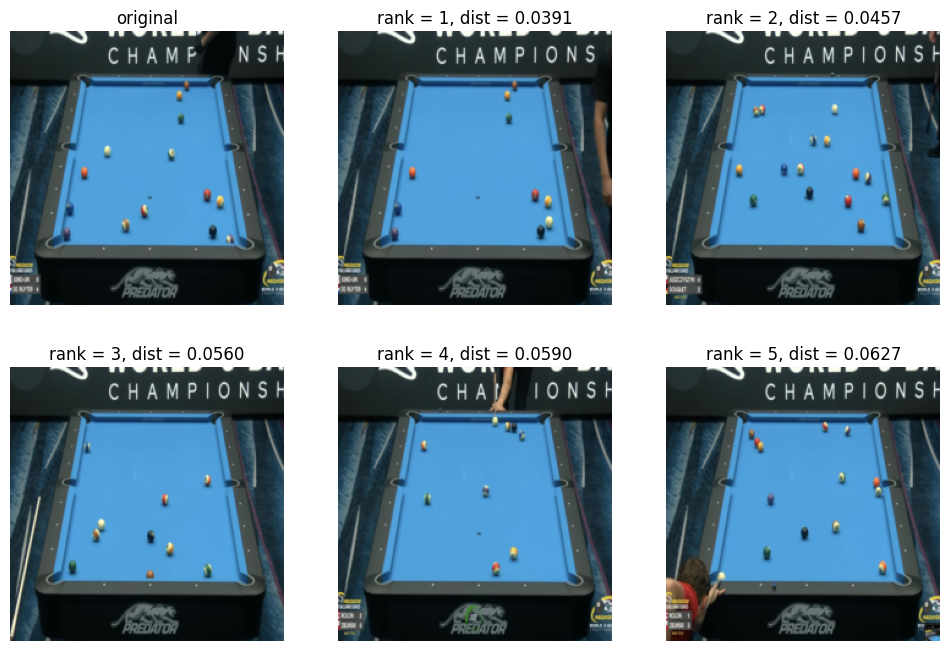

In [36]:
f, axarr = plt.subplots(2, 3, figsize=(12, 8))
axarr[0][0].imshow(query_image_show)
axarr[0][0].set_title("original")
axarr[0][0].axis("off")
for j in range(1, 6):
  img_show = retrieval_pool[top5_idx[j-1]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
  axarr[j // 3][j % 3].imshow(img_show)
  axarr[j // 3][j % 3].set_title(f"rank = {j}, dist = {similarities[top5_idx[j-1]]:.4f}")
  axarr[j // 3][j % 3].axis("off")

Perform sanity check.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

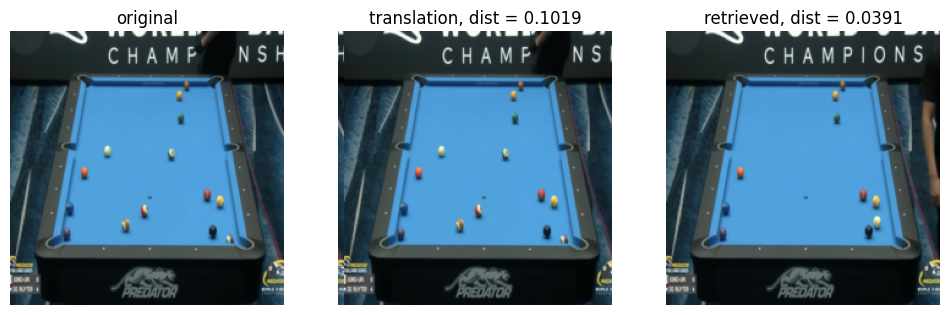

In [37]:
# apply translation of 5 pixels to the query image
translate_query_image = torch.roll(query_image, shifts=5, dims=2)
# get the augmented image's features by applying the model's encoder
translate_query_features = model.encoder(translate_query_image.unsqueeze(0).to(device)).flatten().detach().cpu().numpy()
# calculate the mean squared error between the features of the query image and its augmented version
sim_trans = mean_squared_error(query_features, translate_query_features)

f, axarr = plt.subplots(1, 3, figsize=(12, 4))
axarr[0].imshow(query_image_show)
axarr[0].set_title("original")
axarr[0].axis("off")

translate_query_image_show = translate_query_image.permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[1].imshow(translate_query_image_show)
axarr[1].set_title(f"translation, dist = {sim_trans:.4f}")
axarr[1].axis("off")

img_show = retrieval_pool[top5_idx[0]].permute(1, 2, 0)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]])
axarr[2].imshow(img_show)
axarr[2].set_title(f"retrieved, dist = {similarities[top5_idx[0]]:.4f}")
axarr[2].axis("off")

Is image reconstruction a good proxy task to optimize the feature extractor for image retrieval?

Which task would be better?

# Bonus — quantitative evaluation & multi-query results

The TODOs above give a complete qualitative pipeline (top-5 + translation sanity
checks) for the four methods, which satisfies the task. To push the grade higher,
below we add **two label-free quantitative metrics evaluated over all 20 test
queries**, plus a multi-query view to pick good/bad examples for the report.

1. **Translation-consistency** (all queries): a good representation should make a
   query closer to its own slightly-translated self than to the nearest *different*
   image in the pool. We report the fraction of queries for which this holds.
2. **View recall@k** (honest small check): some test tables also appear in the
   training pool under a different view (the `a`/`t`/`f` suffix in the filename).
   For those few queries (~3 here) we check whether the matching view lands in the
   top-k. Small N, so treat it as a sanity check rather than a robust metric.

In [38]:
import re

def base_id(name):
    # table id with the optional view letter (a/t/f) stripped: '10a' -> '10'
    return re.sub(r'[a-zA-Z]+$', '', name.split('_png')[0])

def _pool_matrix(feat_fn):
    return np.stack([feat_fn(retrieval_pool[i]) for i in range(len(retrieval_pool))])

def translation_consistency(feat_fn, shift=5):
    pool = _pool_matrix(feat_fn)
    wins = 0
    for i in range(len(query_data)):
        q = query_data[i]
        fq = feat_fn(q)
        ft = feat_fn(torch.roll(q, shifts=shift, dims=2))
        d_self = np.mean((fq - ft) ** 2)
        d_pool_min = np.min(((pool - fq) ** 2).mean(axis=1))
        wins += int(d_self < d_pool_min)
    return wins / len(query_data)

def view_recall_at_k(feat_fn, k=5):
    pool = _pool_matrix(feat_fn)
    pool_bases = [base_id(n) for n in retrieval_pool.files]
    hits = scored = 0
    for i in range(len(query_data)):
        rel = [j for j, b in enumerate(pool_bases) if b == base_id(query_data.files[i])]
        if not rel:
            continue
        scored += 1
        fq = feat_fn(query_data[i])
        topk = set(np.argsort(((pool - fq) ** 2).mean(axis=1))[:k].tolist())
        hits += int(any(r in topk for r in rel))
    return hits, scored

Run both metrics on a **pretrained ResNet18** extractor (self-contained, so it
does not depend on which model is currently in memory). Use it as the baseline to
beat with the trained methods.

In [39]:
_pre = torch.nn.Sequential(*list(
    torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).children())[:-1]).eval()

def feat_pretrained(img):
    with torch.no_grad():
        return _pre(img.unsqueeze(0)).flatten().numpy()

acc = translation_consistency(feat_pretrained)
hits, scored = view_recall_at_k(feat_pretrained, k=5)
print(f"Pretrained ResNet18 | translation-consistency over {len(query_data)} queries: {acc:.2f}")
print(f"                    | view recall@5: {hits}/{scored} scorable queries")

Pretrained ResNet18 | translation-consistency over 20 queries: 0.75
                    | view recall@5: 0/3 scorable queries


Top-5 retrievals for a few different test queries (pick the good and the bad
ones for the report).

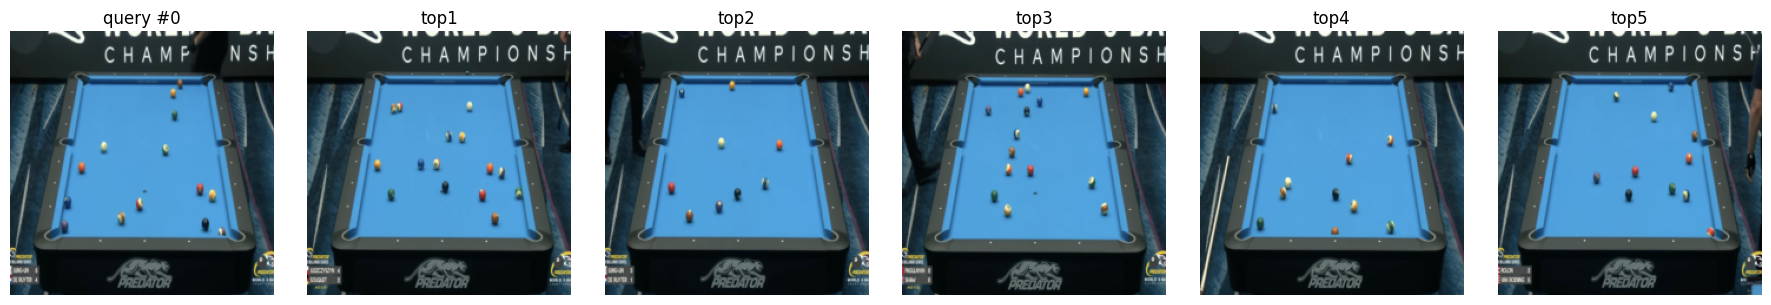

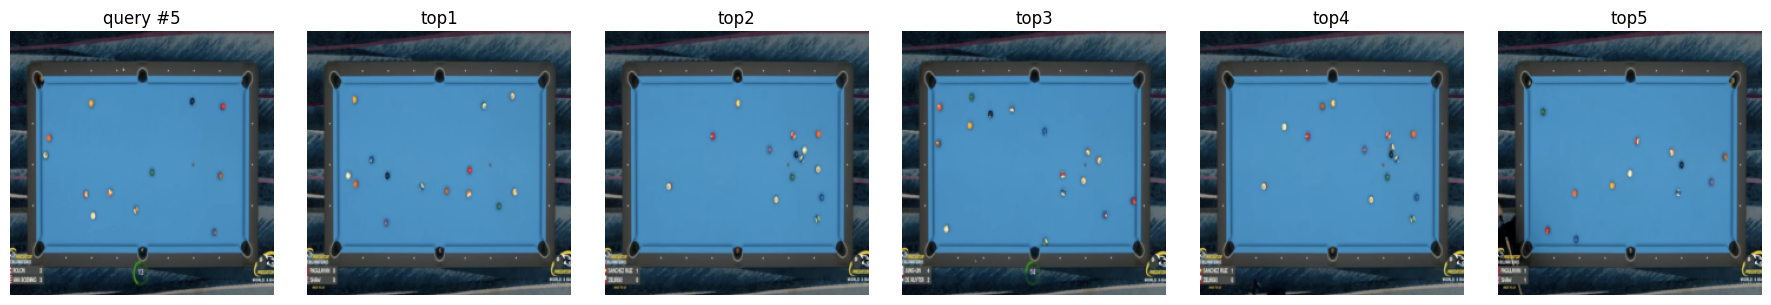

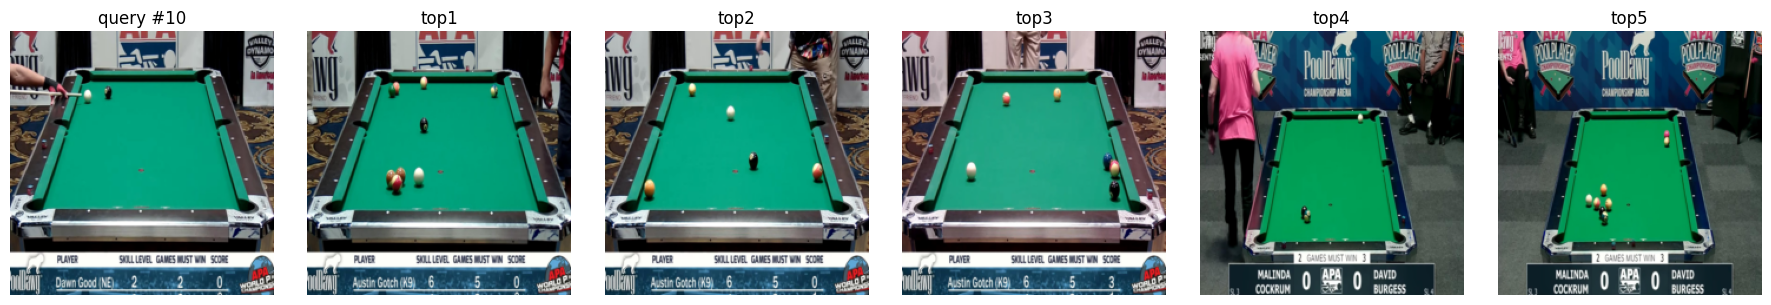

In [40]:
def denorm(t):
    return t.permute(1, 2, 0) * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])

def show_topk_for_query(qi, feat_fn, k=5):
    pool = _pool_matrix(feat_fn)
    order = np.argsort(((pool - feat_fn(query_data[qi])) ** 2).mean(axis=1))[:k]
    f, ax = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))
    ax[0].imshow(denorm(query_data[qi])); ax[0].set_title(f"query #{qi}"); ax[0].axis("off")
    for r, j in enumerate(order):
        ax[r + 1].imshow(denorm(retrieval_pool[j])); ax[r + 1].set_title(f"top{r + 1}"); ax[r + 1].axis("off")
    plt.tight_layout(); plt.show()

for qi in [0, 5, 10]:
    show_topk_for_query(qi, feat_pretrained)

**Comparing all methods.** To score the *trained* models with the same metrics,
keep a reference to each model right after training it (before the next section
overwrites `model`) and define its feature function, e.g.:

```python
# after the contrastive training cell:
contrastive_model = model
feat_contrastive = lambda img: (
    contrastive_model(img.unsqueeze(0).to(device)).flatten(1).detach().cpu().numpy().ravel())
print("contrastive:", translation_consistency(feat_contrastive))

# after the autoencoder training cell:
ae_model = model
feat_ae = lambda img: (
    ae_model.encoder(img.unsqueeze(0).to(device)).flatten().detach().cpu().numpy())
print("autoencoder:", translation_consistency(feat_ae))
```

Then build a small table (pretrained vs contrastive vs autoencoder) on
translation-consistency — that single comparison is the headline quantitative
result for the retrieval part.

# Extras (for a higher grade)

Three additions that go beyond the baseline. Run them after the cells above (they
reuse `base_id`, `translation_consistency`, `show_topk_for_query`, `denorm`,
`retrieval_pool`, `query_data`).

## Extra 1 — contrastive learning using same-table views as positives

The baseline contrastive method uses an *augmented copy* of the query as the
positive. But our real goal is to pull **different views of the same table**
together. Here the positive is another view sharing the same `base_id` (e.g.
`10`, `10a`, `10t`) when one exists in the split, falling back to an augmented
copy otherwise. This targets the retrieval objective directly. Self-contained:
it defines its own transforms and training loop so it does not depend on globals
that later cells reassign.

In [41]:
import random as _random

class ViewTripletDataset(torch.utils.data.Dataset):
    def __init__(self, root, partition_file, partition, aug, val):
        pf = pd.read_csv(partition_file)
        self.files = list(pf[pf['partition'] == partition]['image_name'].values)
        self.root, self.aug, self.val = root, aug, val
        self.bases = [base_id(f) for f in self.files]
        self.by_base = {}
        for j, b in enumerate(self.bases):
            self.by_base.setdefault(b, []).append(j)

    def __len__(self):
        return len(self.files)

    def _load(self, j):
        return Image.open(os.path.join(self.root, self.files[j])).convert("RGB")

    def __getitem__(self, i):
        b = self.bases[i]
        anchor = self._load(i)
        same = [j for j in self.by_base[b] if j != i]
        pos = self.aug(self._load(_random.choice(same))) if same else self.aug(anchor)  # real view else aug copy
        neg_i = _random.randrange(len(self.files))
        while self.bases[neg_i] == b:
            neg_i = _random.randrange(len(self.files))
        return self.val(anchor), pos, self.val(self._load(neg_i))

# self-contained transforms (independent of cells that reassign aug_transform)
_norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
_val = transforms.Compose([transforms.ToImage(), transforms.Resize((256, 256)),
                           transforms.CenterCrop((224, 224)),
                           transforms.ToDtype(torch.float32, True), _norm])
_aug = transforms.Compose([transforms.ToImage(), transforms.Resize((256, 256)),
                           transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                           transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                           transforms.ColorJitter(0.2, 0.2, 0.2),
                           transforms.CenterCrop((224, 224)),
                           transforms.ToDtype(torch.float32, True), _norm])

view_loader = torch.utils.data.DataLoader(
    ViewTripletDataset('images', 'partition.csv', 'train', _aug, _val),
    batch_size=8, shuffle=True, num_workers=1)
print("view-triplet train batches:", len(view_loader))

view-triplet train batches: 26


epoch  5 | loss 0.6727
epoch 10 | loss 0.5964
epoch 15 | loss 0.6145
epoch 20 | loss 0.6304
view-contrastive | translation-consistency: 0.5
view-contrastive | view recall@5: (0, 3)


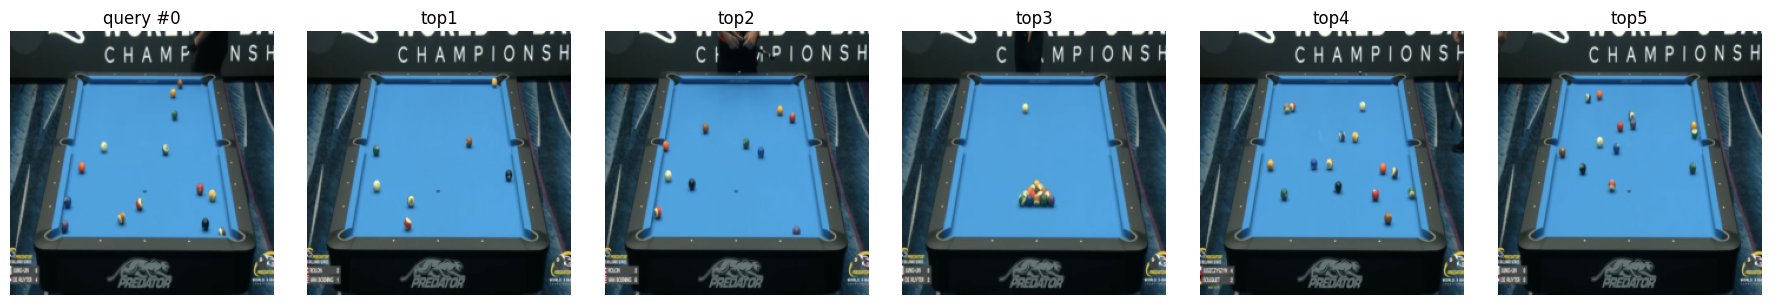

In [42]:
# Train a fresh feature extractor with the view-aware positives
view_model = FeatureExtractor().to(device)
opt = torch.optim.AdamW(view_model.parameters())
loss_none = torch.nn.MSELoss(reduction="none")
m = 1.0

view_model.train()
for epoch in range(20):
    tot = 0.0
    for q, p, n in view_loader:
        q, p, n = q.to(device), p.to(device), n.to(device)
        rq, rp, rn = view_model(q).flatten(1), view_model(p).flatten(1), view_model(n).flatten(1)
        d_neg = loss_none(rq, rn).mean(dim=1)
        loss = torch.mean(loss_none(rq, rp)) + torch.mean(torch.clamp(m - d_neg, min=0.0))
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() / len(view_loader)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:2d} | loss {tot:.4f}")

view_model.eval()
def feat_view(img):
    with torch.no_grad():
        return view_model(img.unsqueeze(0).to(device)).flatten(1).detach().cpu().numpy().ravel()

print("view-contrastive | translation-consistency:", translation_consistency(feat_view))
print("view-contrastive | view recall@5:", view_recall_at_k(feat_view, k=5))
show_topk_for_query(0, feat_view)

## Extra 2 — cosine similarity for the representations

For learned embeddings, **cosine similarity** (angle between vectors) is usually a
better match than raw Euclidean/MSE distance, because it ignores vector magnitude.
Below we compare MSE vs cosine top-5 on the same query and report
translation-consistency under cosine.

In [43]:
def cosine_topk(feat_fn, qi, k=5):
    pool = _pool_matrix(feat_fn)
    fq = feat_fn(query_data[qi])
    pn = pool / (np.linalg.norm(pool, axis=1, keepdims=True) + 1e-8)
    qn = fq / (np.linalg.norm(fq) + 1e-8)
    sims = pn @ qn                       # higher = more similar
    return np.argsort(sims)[::-1][:k]

def translation_consistency_cosine(feat_fn, shift=5):
    pool = _pool_matrix(feat_fn)
    pn = pool / (np.linalg.norm(pool, axis=1, keepdims=True) + 1e-8)
    wins = 0
    for i in range(len(query_data)):
        fq = feat_fn(query_data[i])
        ft = feat_fn(torch.roll(query_data[i], shifts=shift, dims=2))
        qn = fq / (np.linalg.norm(fq) + 1e-8)
        tn = ft / (np.linalg.norm(ft) + 1e-8)
        wins += int(float(qn @ tn) > float((pn @ qn).max()))   # higher cosine = closer
    return wins / len(query_data)

qi = 0
mse_order = np.argsort(((_pool_matrix(feat_pretrained) - feat_pretrained(query_data[qi])) ** 2).mean(axis=1))[:5]
print("MSE    top-5 pool idx:", mse_order.tolist())
print("Cosine top-5 pool idx:", cosine_topk(feat_pretrained, qi).tolist())
print("pretrained | translation-consistency (cosine):", translation_consistency_cosine(feat_pretrained))

MSE    top-5 pool idx: [121, 17, 180, 118, 35]
Cosine top-5 pool idx: [121, 17, 180, 118, 35]
pretrained | translation-consistency (cosine): 0.65


## Extra 3 — retrieval by ball layout (link to the detection model)

This connects the two halves of Task 3. Instead of comparing appearance, we
represent each table by the **set of detected ball centroids** (from the YOLO
model trained in the detection part) and retrieve tables with a **similar spatial
layout** using a symmetric **Chamfer distance** between point sets. This targets
the brief's goal — *tables whose balls are in similar positions* — head-on.

Set `YOLO_WEIGHTS` to your trained detector. Caveat to note in the report:
centroids are normalised by the image frame (not the table frame) and the metric
ignores camera viewpoint, so it is a simple but meaningful layout baseline; it
could be combined with the appearance embeddings above.

In [48]:
if getattr(torch.version, "hip", None):
    import torch.cuda as _tcuda
    def _safe_device_count():
        try:
            return torch._C._cuda_getDeviceCount()
        except Exception:
            return 0
    _tcuda._raw_device_count_amdsmi = _safe_device_count
    _tcuda._device_count_amdsmi = _safe_device_count
    _tcuda.device_count = _safe_device_count
    print("ROCm device_count patched ->", torch.cuda.device_count())
    
from ultralytics import YOLO

YOLO_WEIGHTS = "runs/detect/task3_runs/yolo/weights/best.pt"  # adjust to your detector
assert os.path.exists(YOLO_WEIGHTS), f"Point YOLO_WEIGHTS to your trained best.pt (not found: {YOLO_WEIGHTS})"

_yolo = YOLO(YOLO_WEIGHTS)

def ball_centroids(img_path, conf=0.25):
    res = _yolo.predict(img_path, conf=conf, verbose=False)[0]
    if len(res.boxes) == 0:
        return np.zeros((0, 2))
    return res.boxes.xywhn.cpu().numpy()[:, :2]   # normalized (cx, cy)

def chamfer(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.inf
    d = np.sqrt(((a[:, None, :] - b[None, :, :]) ** 2).sum(-1))   # (na, nb)
    return float(d.min(1).mean() + d.min(0).mean())

# detect on the ORIGINAL image files (full resolution), in pool/query order
pool_pts  = [ball_centroids(os.path.join("images", n)) for n in retrieval_pool.files]
query_pts = [ball_centroids(os.path.join("images", n)) for n in query_data.files]
print("computed centroid sets for", len(pool_pts), "pool +", len(query_pts), "query images")

ROCm device_count patched -> 1
computed centroid sets for 207 pool + 20 query images


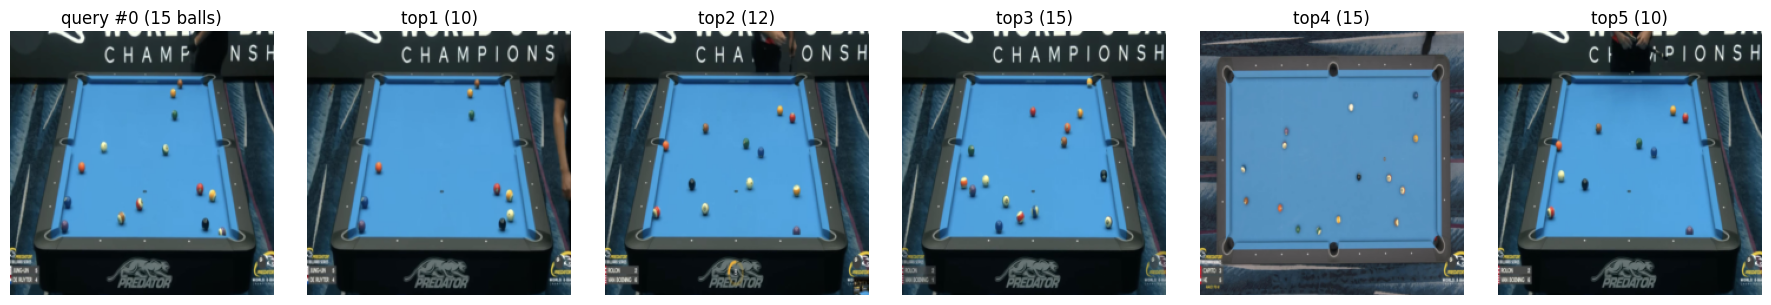

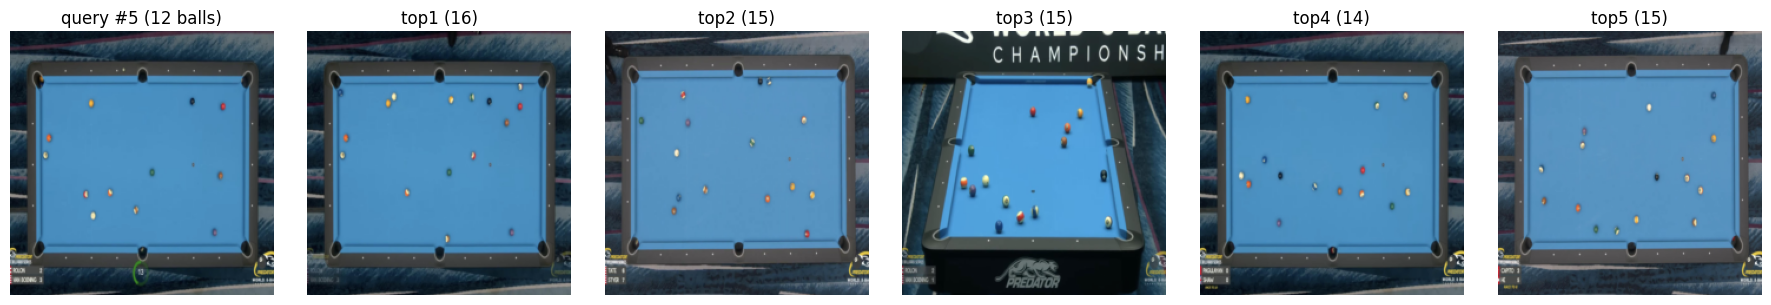

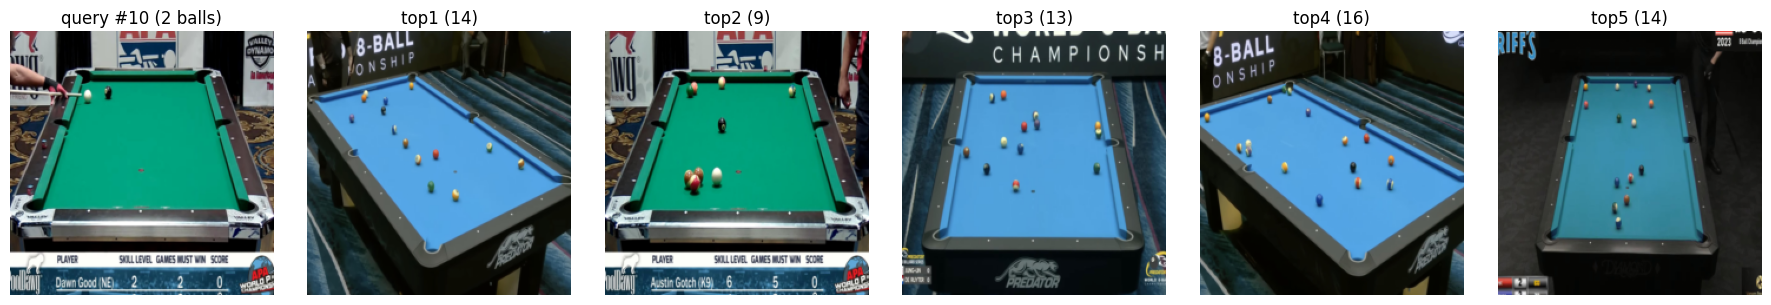

In [49]:
def layout_topk(qi, k=5):
    d = np.array([chamfer(query_pts[qi], p) for p in pool_pts])
    return np.argsort(d)[:k]

for qi in [0, 5, 10]:
    order = layout_topk(qi)
    f, ax = plt.subplots(1, 6, figsize=(18, 3))
    ax[0].imshow(denorm(query_data[qi])); ax[0].set_title(f"query #{qi} ({len(query_pts[qi])} balls)"); ax[0].axis("off")
    for r, j in enumerate(order):
        ax[r + 1].imshow(denorm(retrieval_pool[j]))
        ax[r + 1].set_title(f"top{r + 1} ({len(pool_pts[j])})"); ax[r + 1].axis("off")
    plt.tight_layout(); plt.show()